In [ ]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix



In [ ]:
df = pd.read_csv(
    "/content/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None
)
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


Extract text and labels

In [ ]:
# Column 5 → tweet text
texts = df[5].astype(str).tolist()

# Column 0 → sentiment (0 = negative, 4 = positive)
labels = df[0].tolist()


Convert sentiment labels to binary

In [ ]:
# Convert 4 to 1 (positive sentiment)
labels = [1 if y == 4 else 0 for y in labels]


Text preprocessing

In [ ]:
clean_texts = []

for text in texts:
    text = text.lower()                          # lowercase
    text = re.sub(r"http\S+", " ", text)         # remove URLs
    text = re.sub(r"@\w+", " ", text)            # remove mentions
    text = re.sub(r"#", " ", text)               # remove hashtag symbol
    text = re.sub(r"\d+", " ", text)             # remove numbers
    text = re.sub(r"[^a-z\s]", " ", text)        # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    clean_texts.append(text)


Split into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    clean_texts, labels, test_size=0.2, random_state=42
)


Convert text into TF-IDF features

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


Train Naive Bayes model

In [ ]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [ ]:
predictions = model.predict(X_test_vec)

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    predictions,
    target_names=["Negative", "Positive"]
))


Accuracy: 0.76913125

Classification Report:

              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77    159494
    Positive       0.77      0.77      0.77    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



Confusion Matrix


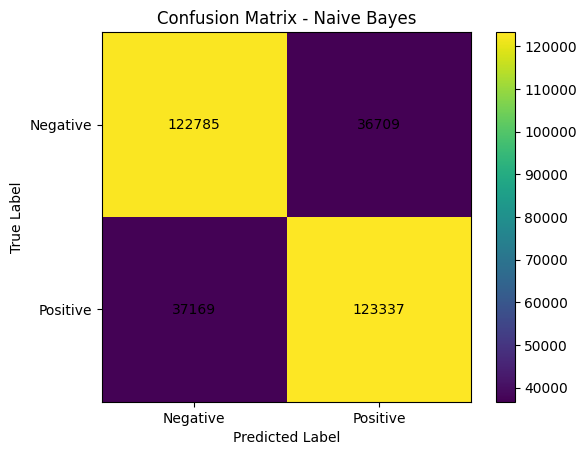

In [ ]:
cm = confusion_matrix(y_test, predictions)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Naive Bayes")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

# Add values manually (no for loop)
plt.text(0, 0, cm[0, 0], ha="center", va="center")
plt.text(1, 0, cm[0, 1], ha="center", va="center")
plt.text(0, 1, cm[1, 0], ha="center", va="center")
plt.text(1, 1, cm[1, 1], ha="center", va="center")

plt.show()


Logistic Regression


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_vec, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
log_predictions = log_model.predict(X_test_vec)


In [ ]:
print("Accuracy:", accuracy_score(y_test, log_predictions))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    log_predictions,
    target_names=["Negative", "Positive"]
))


Accuracy: 0.784665625

Classification Report:

              precision    recall  f1-score   support

    Negative       0.80      0.76      0.78    159494
    Positive       0.77      0.81      0.79    160506

    accuracy                           0.78    320000
   macro avg       0.79      0.78      0.78    320000
weighted avg       0.79      0.78      0.78    320000



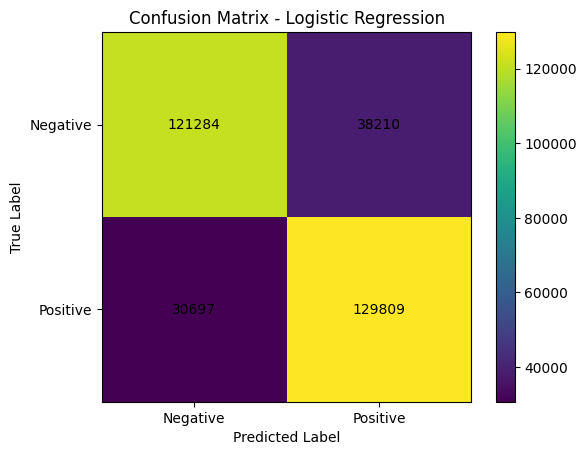

In [ ]:
cm_log = confusion_matrix(y_test, log_predictions)

plt.figure()
plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.text(0, 0, cm_log[0, 0], ha="center", va="center")
plt.text(1, 0, cm_log[0, 1], ha="center", va="center")
plt.text(0, 1, cm_log[1, 0], ha="center", va="center")
plt.text(1, 1, cm_log[1, 1], ha="center", va="center")

plt.show()


SVM

In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)


LinearSVC()

In [ ]:
svm_predictions = svm_model.predict(X_test_vec)


In [ ]:
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    svm_predictions,
    target_names=["Negative", "Positive"]
))


Accuracy: 0.7817875

Classification Report:

              precision    recall  f1-score   support

    Negative       0.80      0.76      0.78    159494
    Positive       0.77      0.81      0.79    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



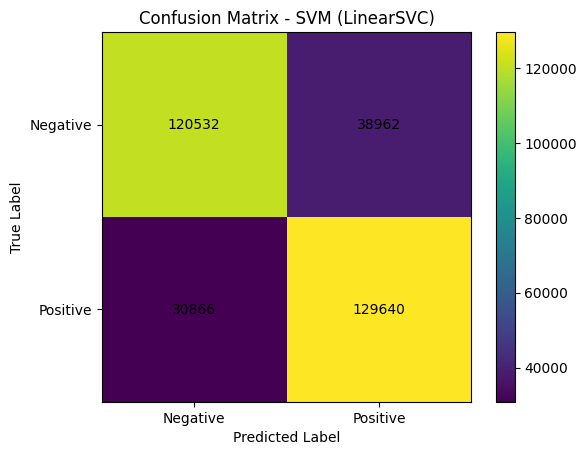

In [ ]:
cm_svm = confusion_matrix(y_test, svm_predictions)

plt.figure()
plt.imshow(cm_svm)
plt.title("Confusion Matrix - SVM (LinearSVC)")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.text(0, 0, cm_svm[0, 0], ha="center", va="center")
plt.text(1, 0, cm_svm[0, 1], ha="center", va="center")
plt.text(0, 1, cm_svm[1, 0], ha="center", va="center")
plt.text(1, 1, cm_svm[1, 1], ha="center", va="center")

plt.show()
